In [1]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from tqdm.notebook import tqdm

# Готовим данные

In [2]:
class ImageData(Dataset):
    def __init__(self , input_path):
        data_file = open(input_path,'r')
        self.data_list = data_file.readlines()
        
        data_file.close()
        self.lengh = len(self.data_list)
        
    def __getitem__(self , index):
        float_list = [float(el) for el in self.data_list[index].split(',')]
        tensor = torch.tensor(float_list, dtype=torch.float)
        
        target = torch.zeros(10)
        target[int(tensor[0])] = 1.0
        
        tensor = tensor[1:]
        
        return tensor/255.0, target
    
    def __len__(self):
        return self.lengh
        

In [3]:
# указываем пути до файлов с данными. Файлы с датасетом надо скачать с GitHub и разархивировать в месте, где лежит файл вашего ноутбука
# или явно указать пути до того места, где вы будете держать файлы датасета
train_path = "/data/mnist_train.csv"
val_path   = "/data/mnist_test.csv"

train_data = ImageData(train_path)
val_data   = ImageData(val_path)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_data, batch_size=16, shuffle=False)

# проверяем размеры загружаемых тензоров
for a,b in val_loader:
    print(a.shape)
    print(b.shape)
    break

torch.Size([16, 784])
torch.Size([16, 10])


# Готовим модель

In [ ]:
class Model1(torch.nn.Module):
    def __init__(self, z_size):
        super(Model1, self).__init__()
        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()
        
        self.L1 = nn.Linear(in_features = 784, out_features = z_size)
        self.L2 = nn.Linear(in_features = z_size, out_features = 10)
        
    def forward(self, x):
        x = self.L1(x)
        x = self.relu(x)
        x = self.L2(x)
        x = self.sigmoid(x)
        
        return x

In [4]:
# задаем функцию потерь
def log_likelihood(output, target):
    loss = nn.BCELoss()
    return loss(output, target)

In [5]:
# проверяем доступа ли GPU, если нет, то считаем все на CPU
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(device)

# создаем объект модели и оптимизатора
model = Model1(z_size = 256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.02)

train_losses = []
val_losses   = []

cpu


# Обучаем модель

In [6]:
n_epochs = 6

for epoch in tqdm(range(n_epochs)):
    model.train()
    train_losses_per_epoch = []
    val_losses_per_epoch   = []
    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data.float().to(device))
        loss = log_likelihood(output, target.to(device))
        loss.backward()
        optimizer.step()
        train_losses_per_epoch.append(loss.item())
        
    train_losses.append(np.mean(train_losses_per_epoch))
    model.eval()
    with torch.no_grad():
        for data, target in val_loader:
            output = model(data.float().to(device))
            loss = log_likelihood(output, target.to(device))
            val_losses_per_epoch.append(loss.item())
        val_losses.append(np.mean(val_losses_per_epoch))

  0%|          | 0/6 [00:00<?, ?it/s]

# Оцениваем точность обученной модели

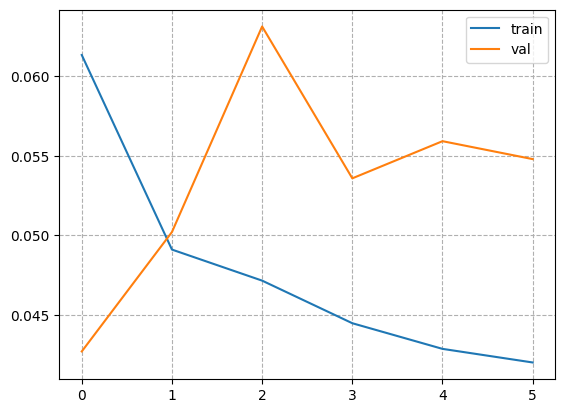

In [7]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.grid(True, linestyle='--')
plt.legend()

In [13]:
s_true = 0
s_false = 0

model.eval()
with torch.no_grad():
    for data, target in val_loader:
        output = model(data.float().to(device))
        
        output_label = torch.argmax(output, dim=1)
        target_label = torch.argmax(target.to(device), dim=1)
        
        for a,b in zip(output_label, target_label):
            if a==b:
                s_true += 1
            else:
                s_false += 1

print(f"точность: {s_true/(s_true+s_false)}")

точность: 0.9415


# Лабораторна работа 4
В примере выше используются неоптимальные значения гиперпараметров и архитектура модели, возникает переобучение. Необходимо оптимизировать этот код чтобы добиться лучшей точности при тестировании.
## 1. Подобрать значения гипрепараметров (batch_size, lr, n_epochs, z_size) и, опционально, архитектуру модели (добавить больше слоев нейронов, использовать другие функции активации и тд) таким образом, чтобы после обучения получить точность >0.955.
## *2. Реализовать обучение сверточной нейронной сети переписав классы ImageData и Model1. Получить точность >0.980

---

### Примечание: 
#### Датасет можно скачать с GitHub в виде файла data.zip (из папки lab4)
#### Для получения максимальной оценки за первый пункт необходимо получить точность не менее 0.970
#### За выполнение задачи со звездочкой можно получить до 5 дополнительных баллов БРС (не распостраняется на сдачу лабораторной работы без защиты).